# EDA – Target, imbalance, credit features, duration leakage – Member 2


In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Find and load the original dataset
possible_paths = [
    Path("../data/raw/bank-additional-full.csv"),
    Path("data/raw/bank-additional-full.csv")
]

DATA_PATH = next(path for path in possible_paths if path.exists())
df = pd.read_csv(DATA_PATH, sep=";")

print("Dataset path:", DATA_PATH)
print("Dataset shape:", df.shape)
df.head()

Dataset path: ..\data\raw\bank-additional-full.csv
Dataset shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [2]:
# Basic data quality checks
print("Column names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())

Column names:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

Missing values:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Number of duplicate rows: 12


,Count,Percentage (%)
y,,
no,36548,88.73
yes,4640,11.27


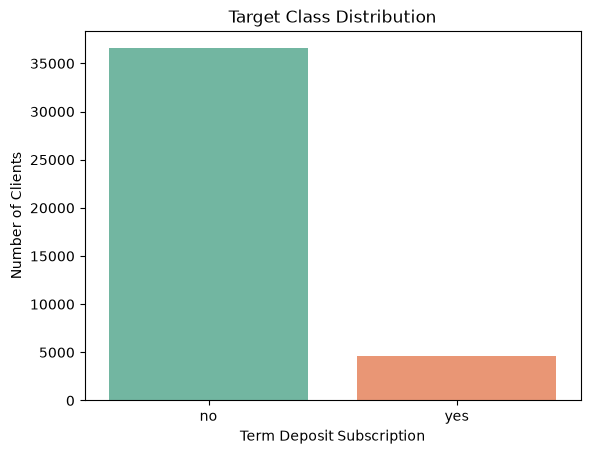

In [3]:
# Target class distribution
target_counts = df["y"].value_counts()
target_percentages = df["y"].value_counts(normalize=True).mul(100).round(2)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage (%)": target_percentages
})

display(target_summary)

sns.countplot(data=df, x="y", hue="y", palette="Set2", legend=False)
plt.title("Target Class Distribution")
plt.xlabel("Term Deposit Subscription")
plt.ylabel("Number of Clients")
plt.show()

### Finding: Target Class Imbalance

The target variable is strongly imbalanced. Out of 41,188 clients, 36,548 (88.73%) did not subscribe to a term deposit, while only 4,640 (11.27%) subscribed. Therefore, accuracy alone is not a suitable evaluation metric because a model predicting every client as "no" would already achieve 88.73% accuracy. PR-AUC, recall, precision, F1-score and ROC-AUC should also be used. Class weights or SMOTE will be evaluated during modelling.

## Credit Feature Analysis

In [4]:
# Credit feature distributions and subscription rates
credit_features = ["default", "housing", "loan"]

for feature in credit_features:
    print(f"\n--- {feature.upper()} ---")
    
    summary = pd.crosstab(
        df[feature],
        df["y"],
        margins=True
    )
    display(summary)

    subscription_rate = (
        df.groupby(feature)["y"]
        .apply(lambda x: (x == "yes").mean() * 100)
        .round(2)
    )
    
    print("Subscription rate (%):")
    display(subscription_rate)


--- DEFAULT ---


y,no,yes,All
default,,,
no,28391,4197,32588
unknown,8154,443,8597
yes,3,0,3
All,36548,4640,41188


Subscription rate (%):


default
no         12.88
unknown     5.15
yes         0.00
Name: y, dtype: float64


--- HOUSING ---


...

housing
no         10.88
unknown    10.81
yes        11.62
Name: y, dtype: float64


--- LOAN ---


y,no,yes,All
loan,,,
no,30100,3850,33950
unknown,883,107,990
yes,5565,683,6248
All,36548,4640,41188


Subscription rate (%):


loan
no         11.34
unknown    10.81
yes        10.93
Name: y, dtype: float64

### Findings: Credit Features

The `default` feature contains 8,597 "unknown" values, showing that missing information is encoded as a category rather than as NaN. Only three clients have `default = yes`, and none subscribed, so this feature may provide very little useful information and should be evaluated for removal.

The subscription rates for the `housing` and `loan` categories are relatively similar. Both features contain 990 "unknown" values. For initial preprocessing, "unknown" will be retained as a separate category so that information is not lost.

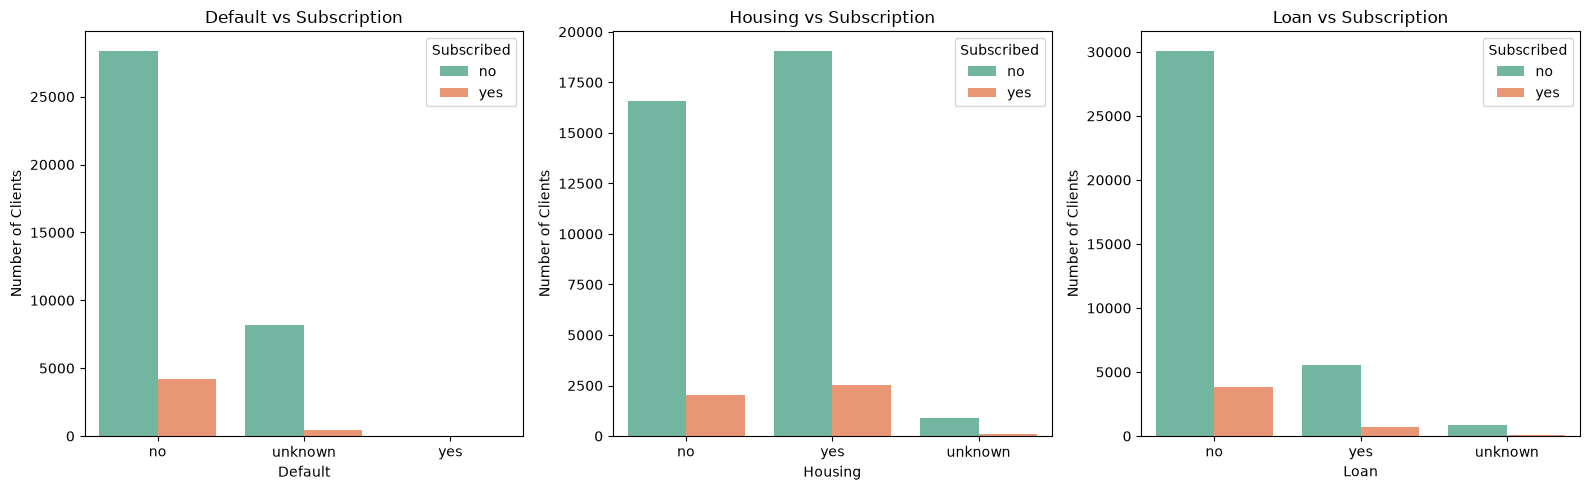

In [5]:
# Visualise credit features against the target
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feature in zip(axes, ["default", "housing", "loan"]):
    sns.countplot(
        data=df,
        x=feature,
        hue="y",
        palette="Set2",
        ax=ax
    )
    ax.set_title(f"{feature.title()} vs Subscription")
    ax.set_xlabel(feature.title())
    ax.set_ylabel("Number of Clients")
    ax.legend(title="Subscribed")

plt.tight_layout()
plt.show()

## Duration Leakage Analysis

,count,mean,median,min,max
y,,,,,
no,36548,220.84,163.5,0,4918
yes,4640,553.19,449.0,37,4199


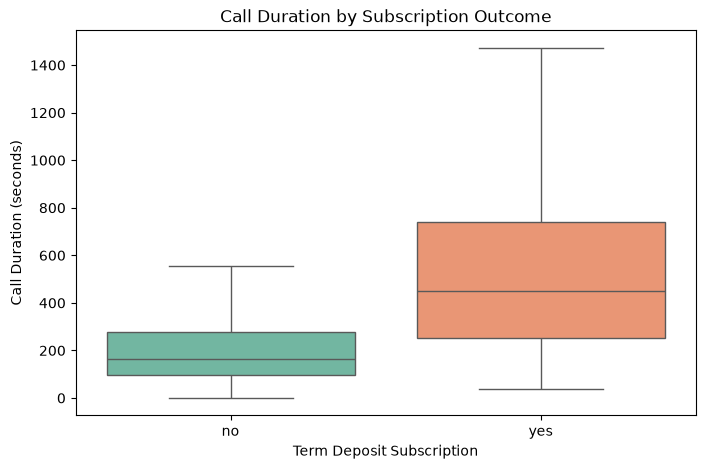

In [6]:
# Compare call duration between target classes
duration_summary = df.groupby("y")["duration"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

display(duration_summary)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="y",
    y="duration",
    hue="y",
    palette="Set2",
    legend=False,
    showfliers=False
)

plt.title("Call Duration by Subscription Outcome")
plt.xlabel("Term Deposit Subscription")
plt.ylabel("Call Duration (seconds)")
plt.show()

### Finding: Duration Data Leakage

Clients who subscribed had a much longer average call duration (553.19 seconds) than clients who did not subscribe (220.84 seconds). The median duration also increased from 163.5 seconds for "no" to 449 seconds for "yes".

However, call duration is only known after the marketing call has ended. Since the objective is to predict subscription probability before making the call, using `duration` would introduce data leakage and produce unrealistically high model performance. Therefore, `duration` will be excluded from the deployable model. A separate benchmark with duration may be used only to demonstrate its inflationary effect.

## Duplicate Removal and Stratified Train-Test Split

In [7]:
from sklearn.model_selection import train_test_split

# Remove exact duplicate rows before splitting
clean_df = df.drop_duplicates().reset_index(drop=True)

print("Rows before duplicate removal:", len(df))
print("Duplicate rows removed:", len(df) - len(clean_df))
print("Rows after duplicate removal:", len(clean_df))

# Separate target and remove the leakage feature
X = clean_df.drop(columns=["y", "duration"])
y = clean_df["y"]

# Stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining set size:", X_train.shape)
print("Test set size:", X_test.shape)

print("\nTraining target percentages:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTest target percentages:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Rows before duplicate removal: 41188
Duplicate rows removed: 12
Rows after duplicate removal: 41176

Training set size: (32940, 19)
Test set size: (8236, 19)

Training target percentages:
y
no     88.73
yes    11.27
Name: proportion, dtype: float64

Test target percentages:
y
no     88.73
yes    11.27
Name: proportion, dtype: float64


### Finding: Cleaning and Data Split

Twelve exact duplicate rows were removed before splitting, reducing the dataset from 41,188 to 41,176 records. The leakage feature `duration` was excluded, leaving 19 predictor features.

A reproducible stratified 80/20 split was created using `random_state=42`. The training set contains 32,940 records and the test set contains 8,236 records. Both sets preserve the original target distribution of 88.73% "no" and 11.27% "yes". This ensures that the minority class is represented proportionally in both datasets.